<a href="https://colab.research.google.com/github/Annsujitra001/Lab-3/blob/main/Lab_3_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import ee
import geemap

ee.Authenticate()
ee.Initialize(project='ee-annsujitra001')

In [ ]:
# ใช้ dataset จังหวัด
provinces = ee.FeatureCollection("FAO/GAUL/2015/level1")

# เลือกจังหวัดนครปฐม
roi = provinces.filter(ee.Filter.eq(
    'ADM1_NAME', 'Nakhon Pathom'
))

# WorldCover
worldcover = ee.Image("ESA/WorldCover/v100/2020").select('Map')

worldcover = ee.Image("ESA/WorldCover/v100/2020").select('Map')

# ตัวอย่าง: เลือกเฉพาะ class ที่ต้องการ
worldcover_filtered = worldcover.updateMask(
    worldcover.eq(40).Or(worldcover.eq(50)).Or(worldcover.eq(60)).Or(worldcover.eq(80))
)

# เลือก class
classes = [40, 50, 60, 80]
new_classes = [0, 1, 2, 3]

lc = worldcover.remap(classes, new_classes).rename('LC')

class_names = {
    0: "Agriculture",
    1: "Urban",
    2: "Bare land",
    3: "Water"
}

def maskS2(image):
    scl = image.select('SCL')

    mask = (
        scl.neq(0)
        .And(scl.neq(1))
        .And(scl.neq(3))
        .And(scl.neq(8))
        .And(scl.neq(9))
        .And(scl.neq(10))
    )

    return image.updateMask(mask)


s2 = (ee.ImageCollection("COPERNICUS/S2_SR")
      .filterBounds(roi)
      .filterDate('2021-01-01', '2021-06-30')
      .map(maskS2)
      .select(['B2','B3','B4','B8','B11'])
      .median())

# NDVI (พืช)
ndvi = s2.normalizedDifference(['B8','B4']).rename('NDVI')

# NDWI (น้ำ)
ndwi = s2.normalizedDifference(['B3','B8']).rename('NDWI')

# NDBI (เมือง)
ndbi = s2.normalizedDifference(['B11','B8']).rename('NDBI')


# รวม band
image = s2.addBands([ndvi, ndwi, ndbi]).addBands(lc).clip(roi)

# แสดงแผนที่
Map = geemap.Map()
Map.centerObject(roi, 9)
Map.addLayer(roi, {}, "Nakhon Pathom")

Map

Map(center=[13.923129520134617, 100.1077792203126], controls=(WidgetControl(options=['position', 'transparent_…

In [ ]:
# รวม band
input_image = image.addBands(worldcover_filtered).clip(roi)

# เช็ค band ก่อน (สำคัญ)
print(input_image.bandNames().getInfo())

# สร้าง sample
sample = input_image.stratifiedSample(
    numPoints=400,
    classBand='Map',
    region=roi,
    scale=10,
    tileScale=8,
    geometries=True
)

# เพิ่ม random
sample = sample.randomColumn('random')

# แบ่ง 80/20
training = sample.filter(ee.Filter.lte('random', 0.8))
validation = sample.filter(ee.Filter.gt('random', 0.8))

# ตรวจสอบจำนวน
print('Training size:', training.size().getInfo())
print('Validation size:', validation.size().getInfo())

# เช็ค class balance
print(training.aggregate_histogram('Map').getInfo())
print(validation.aggregate_histogram('Map').getInfo())

['B2', 'B3', 'B4', 'B8', 'B11', 'NDVI', 'NDWI', 'NDBI', 'LC', 'Map']
Training size: 1254
Validation size: 346
{'40': 315, '50': 323, '60': 305, '80': 311}
{'40': 85, '50': 77, '60': 95, '80': 89}


In [ ]:
classifier = ee.Classifier.smileRandomForest(100).train(
    features=training,
    classProperty='Map',
    inputProperties=['B2','B3','B4','B8','B11','NDVI','NDWI','NDBI']
)

classified = input_image.classify(classifier)


In [ ]:
validation_pred = classified.sampleRegions(
    collection=validation,
    properties=['Map'],
    scale=10
)

In [ ]:
conf_matrix = validation_pred.errorMatrix('Map', 'classification')

In [ ]:
oa = conf_matrix.accuracy()
kappa = conf_matrix.kappa()

In [ ]:
# Convert Confusion Matrix to numpy
import numpy as np
cm = np.array(conf_matrix.getInfo())

# Overall metrics
oa_val = oa.getInfo()
kappa_val = kappa.getInfo()

# Precision / Recall / F1 (per class)
precision = []
recall = []
f1 = []

for i in range(len(cm)):
    tp = cm[i, i]
    fp = np.sum(cm[:, i]) - tp
    fn = np.sum(cm[i, :]) - tp

    p = tp / (tp + fp) if (tp + fp) != 0 else 0
    r = tp / (tp + fn) if (tp + fn) != 0 else 0

    precision.append(p)
    recall.append(r)
    f1.append(2*p*r/(p+r) if (p+r) != 0 else 0)

# แสดงค่าแบบสั้น
print("📊 Model Evaluation Summary")
print(f"Overall Accuracy: {oa_val:.3f}")
print(f"Kappa: {kappa_val:.3f}")
print(f"Mean Precision: {np.mean(precision):.3f}")
print(f"Mean Recall: {np.mean(recall):.3f}")
print(f"Mean F1-score: {np.mean(f1):.3f}")

📊 Model Evaluation Summary
Overall Accuracy: 0.662
Kappa: 0.550
Mean Precision: 0.032
Mean Recall: 0.033
Mean F1-score: 0.032


# comparision

In [ ]:
bands = image.bandNames()

In [ ]:
# Random Forest (ปรับต้นไม้)
rf_50 = ee.Classifier.smileRandomForest(50).train(
    features=training,
    classProperty='Map',
    inputProperties=bands
)

rf_100 = ee.Classifier.smileRandomForest(100).train(
    features=training,
    classProperty='Map',
    inputProperties=bands
)

# SVM
svm = ee.Classifier.libsvm().train(
    features=training,
    classProperty='Map',
    inputProperties=bands
)

In [ ]:
rf50_val = validation.classify(rf_50)
rf100_val = validation.classify(rf_100)
svm_val = validation.classify(svm)

rf50_cm = rf50_val.errorMatrix('Map', 'classification')
rf100_cm = rf100_val.errorMatrix('Map', 'classification')
svm_cm = svm_val.errorMatrix('Map', 'classification')

In [ ]:
def basic_metrics(cm):
    return {
        'OA': cm.accuracy().getInfo(),
        'Kappa': cm.kappa().getInfo()
    }

print('RF 50:', basic_metrics(rf50_cm))
print('RF 100:', basic_metrics(rf100_cm))
print('SVM:', basic_metrics(svm_cm))

RF 50: {'OA': 0.9971098265895953, 'Kappa': 0.9961387376127132}
RF 100: {'OA': 0.9971098265895953, 'Kappa': 0.9961387376127132}
SVM: {'OA': 0.9855491329479769, 'Kappa': 0.9807018718068848}


In [ ]:
import numpy as np

def class_metrics(cm):
    cm = np.array(cm.getInfo())
    precision = []
    recall = []
    f1 = []

    for i in range(len(cm)):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp

        p = tp / (tp + fp) if (tp + fp) != 0 else 0
        r = tp / (tp + fn) if (tp + fn) != 0 else 0
        f = 2 * p * r / (p + r) if (p + r) != 0 else 0

        precision.append(round(p, 3))
        recall.append(round(r, 3))
        f1.append(round(f, 3))

    return precision, recall, f1

In [ ]:
def print_metrics(name, cm):
    print(f'\n=== {name} ===')

    oa = cm.accuracy().getInfo()
    kappa = cm.kappa().getInfo()
    p, r, f1 = class_metrics(cm)

    print('Overall Accuracy:', round(oa, 3))
    print('Kappa:', round(kappa, 3))

    print('\nClass-wise Metrics')
    for i in range(len(p)):
        print(f'Class {i}: Precision={p[i]}, Recall={r[i]}, F1={f1[i]}')

# แสดงผล
print_metrics('RF 50 Trees', rf50_cm)
print_metrics('RF 100 Trees', rf100_cm)
print_metrics('SVM', svm_cm)


=== RF 50 Trees ===
Overall Accuracy: 0.997
Kappa: 0.996

Class-wise Metrics
Class 0: Precision=0, Recall=0, F1=0
Class 1: Precision=0, Recall=0, F1=0
Class 2: Precision=0, Recall=0, F1=0
Class 3: Precision=0, Recall=0, F1=0
Class 4: Precision=0, Recall=0, F1=0
Class 5: Precision=0, Recall=0, F1=0
Class 6: Precision=0, Recall=0, F1=0
Class 7: Precision=0, Recall=0, F1=0
Class 8: Precision=0, Recall=0, F1=0
Class 9: Precision=0, Recall=0, F1=0
Class 10: Precision=0, Recall=0, F1=0
Class 11: Precision=0, Recall=0, F1=0
Class 12: Precision=0, Recall=0, F1=0
Class 13: Precision=0, Recall=0, F1=0
Class 14: Precision=0, Recall=0, F1=0
Class 15: Precision=0, Recall=0, F1=0
Class 16: Precision=0, Recall=0, F1=0
Class 17: Precision=0, Recall=0, F1=0
Class 18: Precision=0, Recall=0, F1=0
Class 19: Precision=0, Recall=0, F1=0
Class 20: Precision=0, Recall=0, F1=0
Class 21: Precision=0, Recall=0, F1=0
Class 22: Precision=0, Recall=0, F1=0
Class 23: Precision=0, Recall=0, F1=0
Class 24: Precision=

Overall Accuracy: 0.986
Kappa: 0.981

Class-wise Metrics
Class 0: Precision=0, Recall=0, F1=0
Class 1: Precision=0, Recall=0, F1=0
Class 2: Precision=0, Recall=0, F1=0
Class 3: Precision=0, Recall=0, F1=0
Class 4: Precision=0, Recall=0, F1=0
Class 5: Precision=0, Recall=0, F1=0
Class 6: Precision=0, Recall=0, F1=0
Class 7: Precision=0, Recall=0, F1=0
Class 8: Precision=0, Recall=0, F1=0
Class 9: Precision=0, Recall=0, F1=0
Class 10: Precision=0, Recall=0, F1=0
Class 11: Precision=0, Recall=0, F1=0
Class 12: Precision=0, Recall=0, F1=0
Class 13: Precision=0, Recall=0, F1=0
Class 14: Precision=0, Recall=0, F1=0
Class 15: Precision=0, Recall=0, F1=0
Class 16: Precision=0, Recall=0, F1=0
Class 17: Precision=0, Recall=0, F1=0
Class 18: Precision=0, Recall=0, F1=0
Class 19: Precision=0, Recall=0, F1=0
Class 20: Precision=0, Recall=0, F1=0
Class 21: Precision=0, Recall=0, F1=0
Class 22: Precision=0, Recall=0, F1=0
Class 23: Precision=0, Recall=0, F1=0
Class 24: Precision=0, Recall=0, F1=0
Cla

In [ ]:
# ดึง importance
importance = classifier.explain().get('importance')

# แปลงเป็น dictionary
importance_dict = ee.Dictionary(importance).getInfo()

# เรียงจากมาก → น้อย
sorted_importance = sorted(importance_dict.items(), key=lambda x: x[1], reverse=True)

print('Feature Importance (sorted):')
for f in sorted_importance:
    print(f)

Feature Importance (sorted):
('B11', 519.2201024038677)
('B8', 509.94074017747545)
('NDBI', 503.3240927849961)
('B2', 500.5655463339288)
('B4', 498.01503722779006)
('NDWI', 484.595987083092)
('NDVI', 478.0174357003771)
('B3', 466.9542779725898)


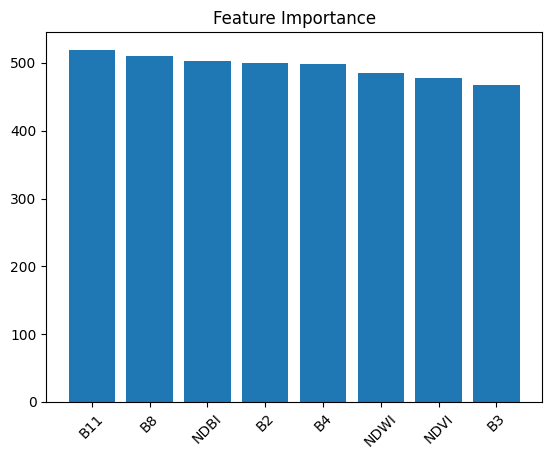

In [ ]:
import matplotlib.pyplot as plt

# แปลง dict → list
features = [i[0] for i in sorted_importance]
values = [i[1] for i in sorted_importance]

plt.figure()
plt.bar(features, values)
plt.xticks(rotation=45)
plt.title('Feature Importance')
plt.show()

In [ ]:
# เลือกเฉพาะ feature สำคัญ
selected_bands = ['B8','NDVI','NDWI','B11']

classifier2 = ee.Classifier.smileRandomForest(100).train(
    features=training,
    classProperty='Map',
    inputProperties=selected_bands
)

validated2 = validation.classify(classifier2)
cm2 = validated2.errorMatrix('Map', 'classification')

print('New Accuracy:', cm2.accuracy().getInfo())

New Accuracy: 0.6560693641618497


In [ ]:
import ee
import geemap

ee.Authenticate()
ee.Initialize(project= 'ee-annsujitra001')

Map = geemap.Map()

# --- classifier ---
prob_classifier = classifier.setOutputMode('MULTIPROBABILITY')
prob = image.classify(prob_classifier)

# --- uncertainty ---
prob_array = prob.toArray()
sorted_prob = prob_array.arraySort()

max1 = sorted_prob.arrayGet([-1])
max2 = sorted_prob.arrayGet([-2])

uncertainty = max1.subtract(max2)

# --- show ---
Map.centerObject(roi, 10)
Map.addLayer(uncertainty, {'min':0, 'max':1}, 'Uncertainty')

Map

Map(center=[13.92312952013463, 100.10777922031261], controls=(WidgetControl(options=['position', 'transparent_…